In [2]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from cVAE import cVAE
from cVAE_ori import cVAE as cVAE_pred
from MDN import mdn, Mixture
from tortreinador.models.MDN import mdn as mdn_ori
from config import output_parameters, input_parameters
from tortreinador.utils.View import init_weights
import warnings
import os
import joblib
from tortreinador.utils.metrics import evaluation
from sklearn.preprocessing import MinMaxScaler
plt.rcParams['axes.grid'] = False
warnings.filterwarnings('ignore')


## Loading models

In [3]:
base_path = '.\\data'
heatmap_save_path = os.path.join(base_path, 'Charts', 'heatmap')
radar_save_path = os.path.join(base_path, 'Charts', 'Radar')
cvae_path = os.path.join(base_path, 'cVAE')
mdn_path = os.path.join(base_path, 'MDN')
project_dir = '.\\imgs'

cvae_degree_ori = os.path.join(cvae_path, 'ori')
cvae_degree_5th = os.path.join(cvae_path, '5th')
cvae_degree_50th = os.path.join(cvae_path, '50th')
cvae_degree_95th = os.path.join(cvae_path, '95th')
mdn_degree_ori = os.path.join(mdn_path, 'ori')
mdn_degree_50th = os.path.join(mdn_path, '50th')

"""
    Original
"""
cvae_ori = cVAE_pred(i_dim=len(output_parameters), z_dim=int(len(output_parameters) * 7), num_hidden=1024, c_dim=len(input_parameters), o_dim=len(output_parameters))
init_weights(cvae_ori)
cvae_ori.load_state_dict(torch.load(os.path.join(cvae_degree_ori, "best_model.pth")))
cvae_decoder_ori = cvae_ori.decoder
cvae_encoder_ori = cvae_ori.encoder

"""
    5th
"""
cvae_5th = cVAE(i_dim=len(output_parameters), z_dim=int(len(output_parameters) * 7), num_hidden=1024, c_dim=len(input_parameters), o_dim=len(output_parameters))
init_weights(cvae_5th)
cvae_5th.load_state_dict(torch.load(os.path.join(cvae_degree_5th, "best_model.pth")))
cvae_decoder_5th = cvae_5th.decoder
cvae_encoder_5th = cvae_5th.encoder

"""
    50th
"""
cvae_50th = cVAE(i_dim=len(output_parameters), z_dim=int(len(output_parameters) * 7), num_hidden=1024, c_dim=len(input_parameters), o_dim=len(output_parameters))
init_weights(cvae_50th)
cvae_50th.load_state_dict(torch.load(os.path.join(cvae_degree_50th, "best_model.pth")))
cvae_decoder_50th = cvae_50th.decoder
cvae_encoder_50th = cvae_50th.encoder

"""
    95th
"""
cvae_95th = cVAE(i_dim=len(output_parameters), z_dim=int(len(output_parameters) * 7), num_hidden=1024, c_dim=len(input_parameters), o_dim=len(output_parameters))
init_weights(cvae_95th)
cvae_95th.load_state_dict(torch.load(os.path.join(cvae_degree_95th, "best_model.pth")))
cvae_decoder_95th = cvae_95th.decoder
cvae_encoder_95th = cvae_95th.encoder

"""
    MDN Original
"""
mdn_original = mdn_ori(input_size=len(input_parameters), output_size=len(output_parameters), num_hidden=512, num_gaussian=10)
init_weights(mdn_original)
mdn_original.load_state_dict(torch.load(os.path.join(mdn_degree_ori, "best_model.pth")))
mix = Mixture()

"""
    50th
"""
mdn_50th = mdn(input_size=len(input_parameters), output_size=len(output_parameters), num_hidden=512, num_gaussian=10)
init_weights(mdn_50th)
mdn_50th.load_state_dict(torch.load(os.path.join(mdn_degree_50th, "best_model.pth")))
# mix = Mixture()


<All keys matched successfully>

## Functions for processing

In [4]:
def variable_scale(y):
    y[:, 5] = y[:, 5] / 1000
    y[:, 6] = y[:, 6] / 1000
    return y

def load_test_data(degree, size: int = 5000):
    scaler_x = joblib.load(os.path.join(degree, 'scaler_x.save'))
    scaler_y = joblib.load(os.path.join(degree, 'scaler_y.save'))
    
    test_x = np.load(os.path.join(degree, 'test_x.npy'))[:size, :]
    test_y = np.load(os.path.join(degree, 'test_y.npy'))[:size, :]
    test_y_inverse = scaler_y.inverse_transform(test_y)
    test_y_inverse = variable_scale(test_y_inverse)
    
    return test_x, test_y, test_y_inverse, scaler_x, scaler_y

def cvae_single_point_inference(decoder, x, scaler_y):
    fake_y = torch.from_numpy(np.random.normal(0, 1, (len(x), 7 * len(output_parameters)))).to(torch.float)
    pred = decoder(fake_y, torch.from_numpy(x).to(torch.float))
    pred = pred.detach().numpy()
    pred_inverse = scaler_y.inverse_transform(pred)
    
    return pred, pred_inverse

def mdn_single_point_inference(mdn_model, x, scaler_y):
    try:
        mdn_pred = mdn_model(torch.from_numpy(x).to(torch.float))
    
    except Exception as e:
        mdn_pred = mdn_model(torch.from_numpy(x).to(torch.double))

    pred = mix(mdn_pred[0], mdn_pred[1], mdn_pred[2]).sample()
    pred = pred.detach().numpy()
    pred_inverse = scaler_y.inverse_transform(pred)
    
    return pred, pred_inverse

def get_evaluation_result(file_path, model, model_type: str):
    test_data = load_test_data(file_path)
    model.eval()
    
    if model_type == 'cVAE':
        pred, _ = cvae_single_point_inference(model, test_data[0], test_data[-1])
    
    elif model_type == 'MDN':
        pred, _ = mdn_single_point_inference(model, test_data[0], test_data[-1])
        
    eva_result = evaluation(test_data[1], pred)
    result_dict = {
            'R$^2$': eva_result[0],
            '1 - MinMax(MSE)': eva_result[1],
            '1 - MinMax(MAE)': eva_result[2],
            '1 - MinMax(RMSE)': eva_result[3],
            '1 - MinMax(MAPE)': eva_result[5],
        }

    return result_dict


## Validating each model, create a dictionary of evaluation results and convert to three different lists

In [7]:
# degree_s = ['ori', '5th', '50th', '95th']
results_dict = {
    'cVAE EF': get_evaluation_result(cvae_degree_ori, cvae_decoder_ori, "cVAE"),
    'MDN EF': get_evaluation_result(mdn_degree_ori, mdn_original, "MDN"),
    'cVAE ($5^{\mathrm{th}}$)': get_evaluation_result(os.path.join(base_path, '5th'), cvae_decoder_5th, "cVAE"),
    'cVAE ($50^{\mathrm{th}}$)': get_evaluation_result(os.path.join(base_path, '50th'), cvae_decoder_50th, "cVAE"),
    'cVAE ($95^{\mathrm{th}}$)': get_evaluation_result(os.path.join(base_path, '95th'), cvae_decoder_95th, "cVAE"),
    'MDN ($50^{\mathrm{th}}$)': get_evaluation_result(os.path.join(base_path, '50th'), mdn_50th, "MDN"),
}

# cvae_ori_eva_result = get_evaluation_result(cvae_degree_ori, cvae_decoder_ori, "cVAE")

R-Square: 0.98258376121521
MSE: 0.0005431888857856393
MAE: 0.01659785956144333
RMSE: 0.022972194477915764
MedAE: 0.01244309265166521
MAPE: 9.002042561769485
Explained Variance: 0.9826394319534302
R-Square: 0.9538240568574057
MSE: 0.0018418933220127759
MAE: 0.02564252061065874
RMSE: 0.04129465783848549
MedAE: 0.016295985792791318
MAPE: 13.019038936497937
Explained Variance: 0.9538776490791496
R-Square: 0.8807979447900929
MSE: 0.005930325059836383
MAE: 0.04768117814748568
RMSE: 0.06656598880282613
MedAE: 0.03417094230172135
MAPE: 32.4012593877101
Explained Variance: 0.880930918321922
R-Square: 0.811144445862877
MSE: 0.009303600573628246
MAE: 0.06292014543138531
RMSE: 0.08494723333339599
MedAE: 0.048006461333604554
MAPE: 38.9448333877958
Explained Variance: 0.8113673801862213
R-Square: 0.5728762297634726
MSE: 0.020827116909411556
MAE: 0.1013515899768049
RMSE: 0.12942110778017674
MedAE: 0.08520826324338648
MAPE: 79.47130745229984
Explained Variance: 0.573373061924437
R-Square: 0.6213005072

In [8]:
radar_value = []
radar_key = []
labels = []
for k, v in results_dict.items():
    tmp_list = list(v.values())
    radar_value.append(tmp_list + tmp_list[:1])
    
    k_split = k.split('_')
    # k_m, k_err = k_split[0], k_split[-1]
    # if k_err != 'Original':
    #     k_err = ' ${}$'.format(k_err.replace('th', '^{th}'))
    # 
    # else:
    #     k_err = ' {}'.format(k_err)
    # 
    # k = k_m + k_err
    radar_key.append(k)
    
    if not labels:
        tmp_labels = list(v.keys())
        # for i in range(len(tmp_labels)):
        #     if tmp_labels[i] != 'R-Square':
        #         tmp_labels[i] = '-' + tmp_labels[i]
                
        labels = tmp_labels

radar_value = np.array(radar_value)

## Using MinMaxScaler to process all metrics except R-Square

In [ ]:
radar_scaler = MinMaxScaler()
radar_value_scaled = 1 - radar_scaler.fit_transform(radar_value[:, 1:-1])
radar_value_scaled = np.hstack([np.expand_dims(radar_value[:, 0], 1), radar_value_scaled, np.expand_dims(radar_value[:, 0], 1)])

# radar_value_scaled = radar_value.copy()
# r_max = 0
# r_min = 0
# 
# for i in range(1, radar_value[:, :-1].shape[1], 1):
#     radar_value_scaled[i] = 1 / (1 + radar_value_scaled[i])
#     current_variable_max = max(radar_value_scaled[i])
#     current_variable_min = min(radar_value_scaled[i])
#     
#     if current_variable_max > r_max:
#         r_max = current_variable_max
#     
#     if current_variable_min < r_min:
#         r_min = current_variable_min

In [10]:
N = len(labels)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]

angles = np.array(angles)

# Plotting

Label: R-Square position process done
Label: 1 - MinMax(MSE) position process done
Label: 1 - MinMax(MAE) position process done
Label: 1 - MinMax(RMSE) position process done
Label: 1 - MinMax(MAPE) position process done


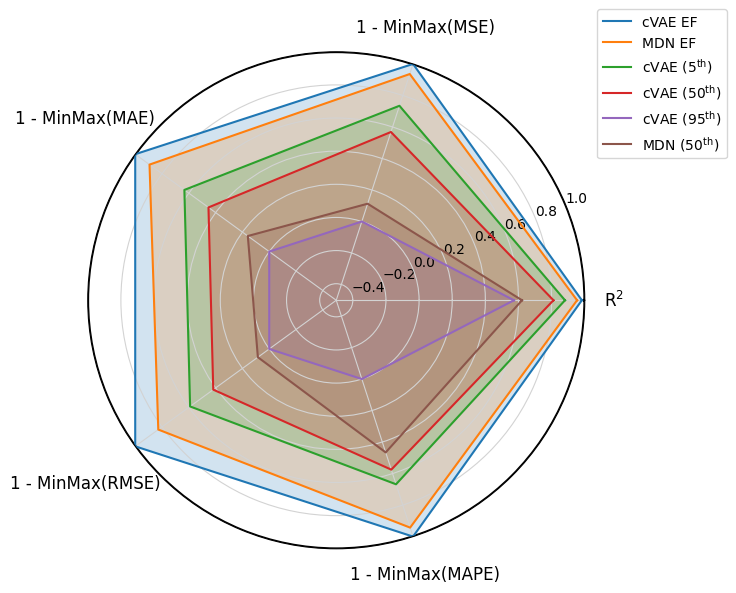

In [11]:
fig, ax = plt.subplots(subplot_kw=dict(polar=True), figsize=(10, 6), facecolor='w')
ax.set_facecolor('w')

for m in range(len(radar_value)):
    ax.plot(angles, radar_value_scaled[m], label=radar_key[m])
    ax.fill(angles, radar_value_scaled[m], alpha=0.2)
    
    # if m == 0:
ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels, fontsize=12)
ax.tick_params(axis='x', colors='black')
ax.tick_params(axis='y', colors='black')

ax.set_ylim(-0.5, 1)       

for i, (angle, label) in enumerate(zip(angles, ax.get_xticklabels())):
    t = label.get_text()
    if t == 'R$^2$':
        label.set_position((angle, 0 - 0.04))
        print("Label: R-Square position process done")
    
    elif t == '1 - MinMax(MSE)':
        label.set_position((angle, 0 - 0.08))
        print("Label: {} position process done".format(t))
        
    elif t == '1 - MinMax(MAE)':
        label.set_position((angle, 0 - 0.17))
        print("Label: {} position process done".format(t))
        
    elif t == '1 - MinMax(RMSE)':
        label.set_position((angle, 0 - 0.17))
        print("Label: {} position process done".format(t))
        
    elif t == '1 - MinMax(MAPE)':
        label.set_position((angle, 0 - 0.08))
        print("Label: {} position process done".format(t))
        
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))

ax.grid(True)
ax.xaxis.grid(True, color='lightgrey', linestyle='-', linewidth=0.8)
ax.yaxis.grid(True, color='lightgrey', linestyle='-', linewidth=0.8)

circles = ax.yaxis.get_gridlines()
if circles:
    outer = circles[-1]
    outer.set_color('black')
    outer.set_linewidth(2.0)

plt.tight_layout()
plt.show()
# fig.savefig(os.path.join(radar_save_path, "cVAE_vs_MDN_Transparent.pdf"), bbox_inches="tight", transparent=True)
# fig.savefig(os.path.join(radar_save_path, "cVAE_vs_MDN.pdf"), bbox_inches="tight", transparent=False)